# Exploratory Data Analysis (EDA) - Obesity Dataset

## 0 - Import Library

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
from sklearn.preprocessing import LabelEncoder

## 1 - Loading Dataset

In [3]:
# Add src to path
sys.path.append(os.path.abspath('../'))
from src.config import RAW_DATA_PATH

df = pd.read_csv(RAW_DATA_PATH)
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2 - Data Overview

In [4]:
df.shape

(2111, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [6]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


## 3 - Check Missing Values

In [7]:
summary = (
    pd.DataFrame({
        "dtype": df.dtypes,
        "Missing Count": df.isnull().sum(),
        "Missing %": df.isnull().mean()*100,
        "Unique": df.nunique()
    })
    .query("`Missing Count` > 0")
    .sort_values("Missing Count", ascending=False)
)

summary.style \
.background_gradient(cmap="Reds", subset=["Missing Count","Missing %"]) \
.format({"Missing %": "{:.1f}%"})

,dtype,Missing Count,Missing %,Unique


## 4 - Check Duplicate

In [45]:
print("=" * 50)
print("DUPLICATE DATA CHECK")
print("=" * 50)

# Total duplicate rows
duplicate_count = df.duplicated().sum()

print(f"\nTotal Duplicate Rows : {duplicate_count}")

# Percentage duplicate
duplicate_percentage = round(
    (duplicate_count / len(df)) * 100,
    2
)

print(f"Duplicate Percentage : {duplicate_percentage}%")

DUPLICATE DATA CHECK

Total Duplicate Rows : 24
Duplicate Percentage : 1.14%


## 5 - Feature Type Identification

In [38]:
print("=" * 60)
print("FEATURES IDENTIFICATION")
print("=" * 60)

numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = df.select_dtypes(
    include=['object']
).columns.tolist()

target_column = "Obesity"

# Remove target from categorical list if exists
if target_column in categorical_features:
    categorical_features.remove(target_column)

print("NUMERICAL FEATURES")
print(numerical_features)

print("\nCATEGORICAL FEATURES")
print(categorical_features)

FEATURES IDENTIFICATION
NUMERICAL FEATURES
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

CATEGORICAL FEATURES
['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


## 6 - Target Analysis

TARGET ANALYSIS
Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


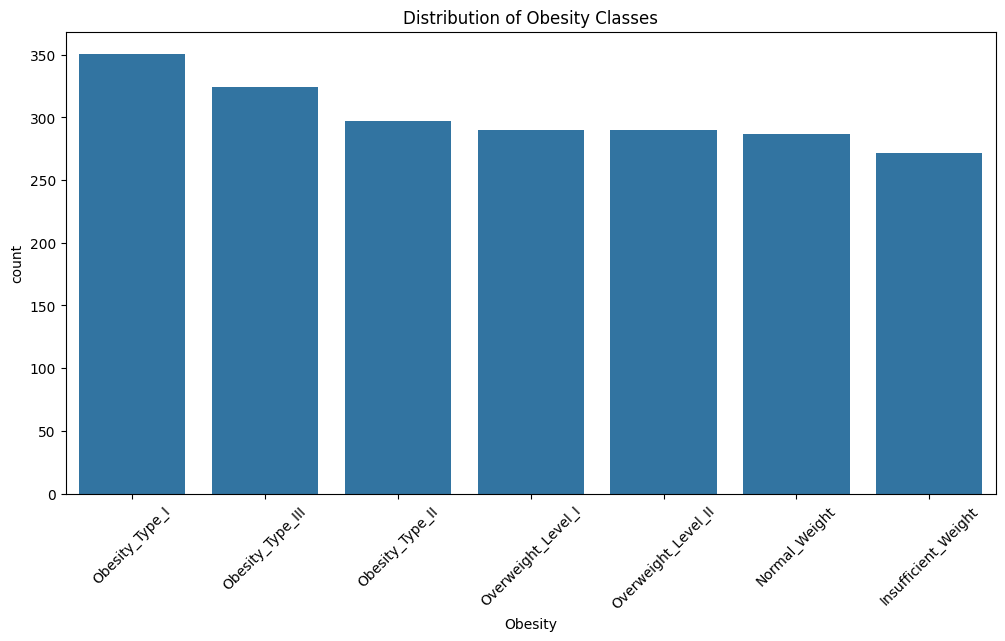

In [47]:
print("=" * 60)
print("TARGET ANALYSIS")
print("=" * 60)

print(df[target_column].value_counts())

# Visualization
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x=target_column,
    order=df[target_column].value_counts().index
)

plt.title("Distribution of Obesity Classes")
plt.xticks(rotation=45)
plt.show()

## 7 - Univariate Features Analysis

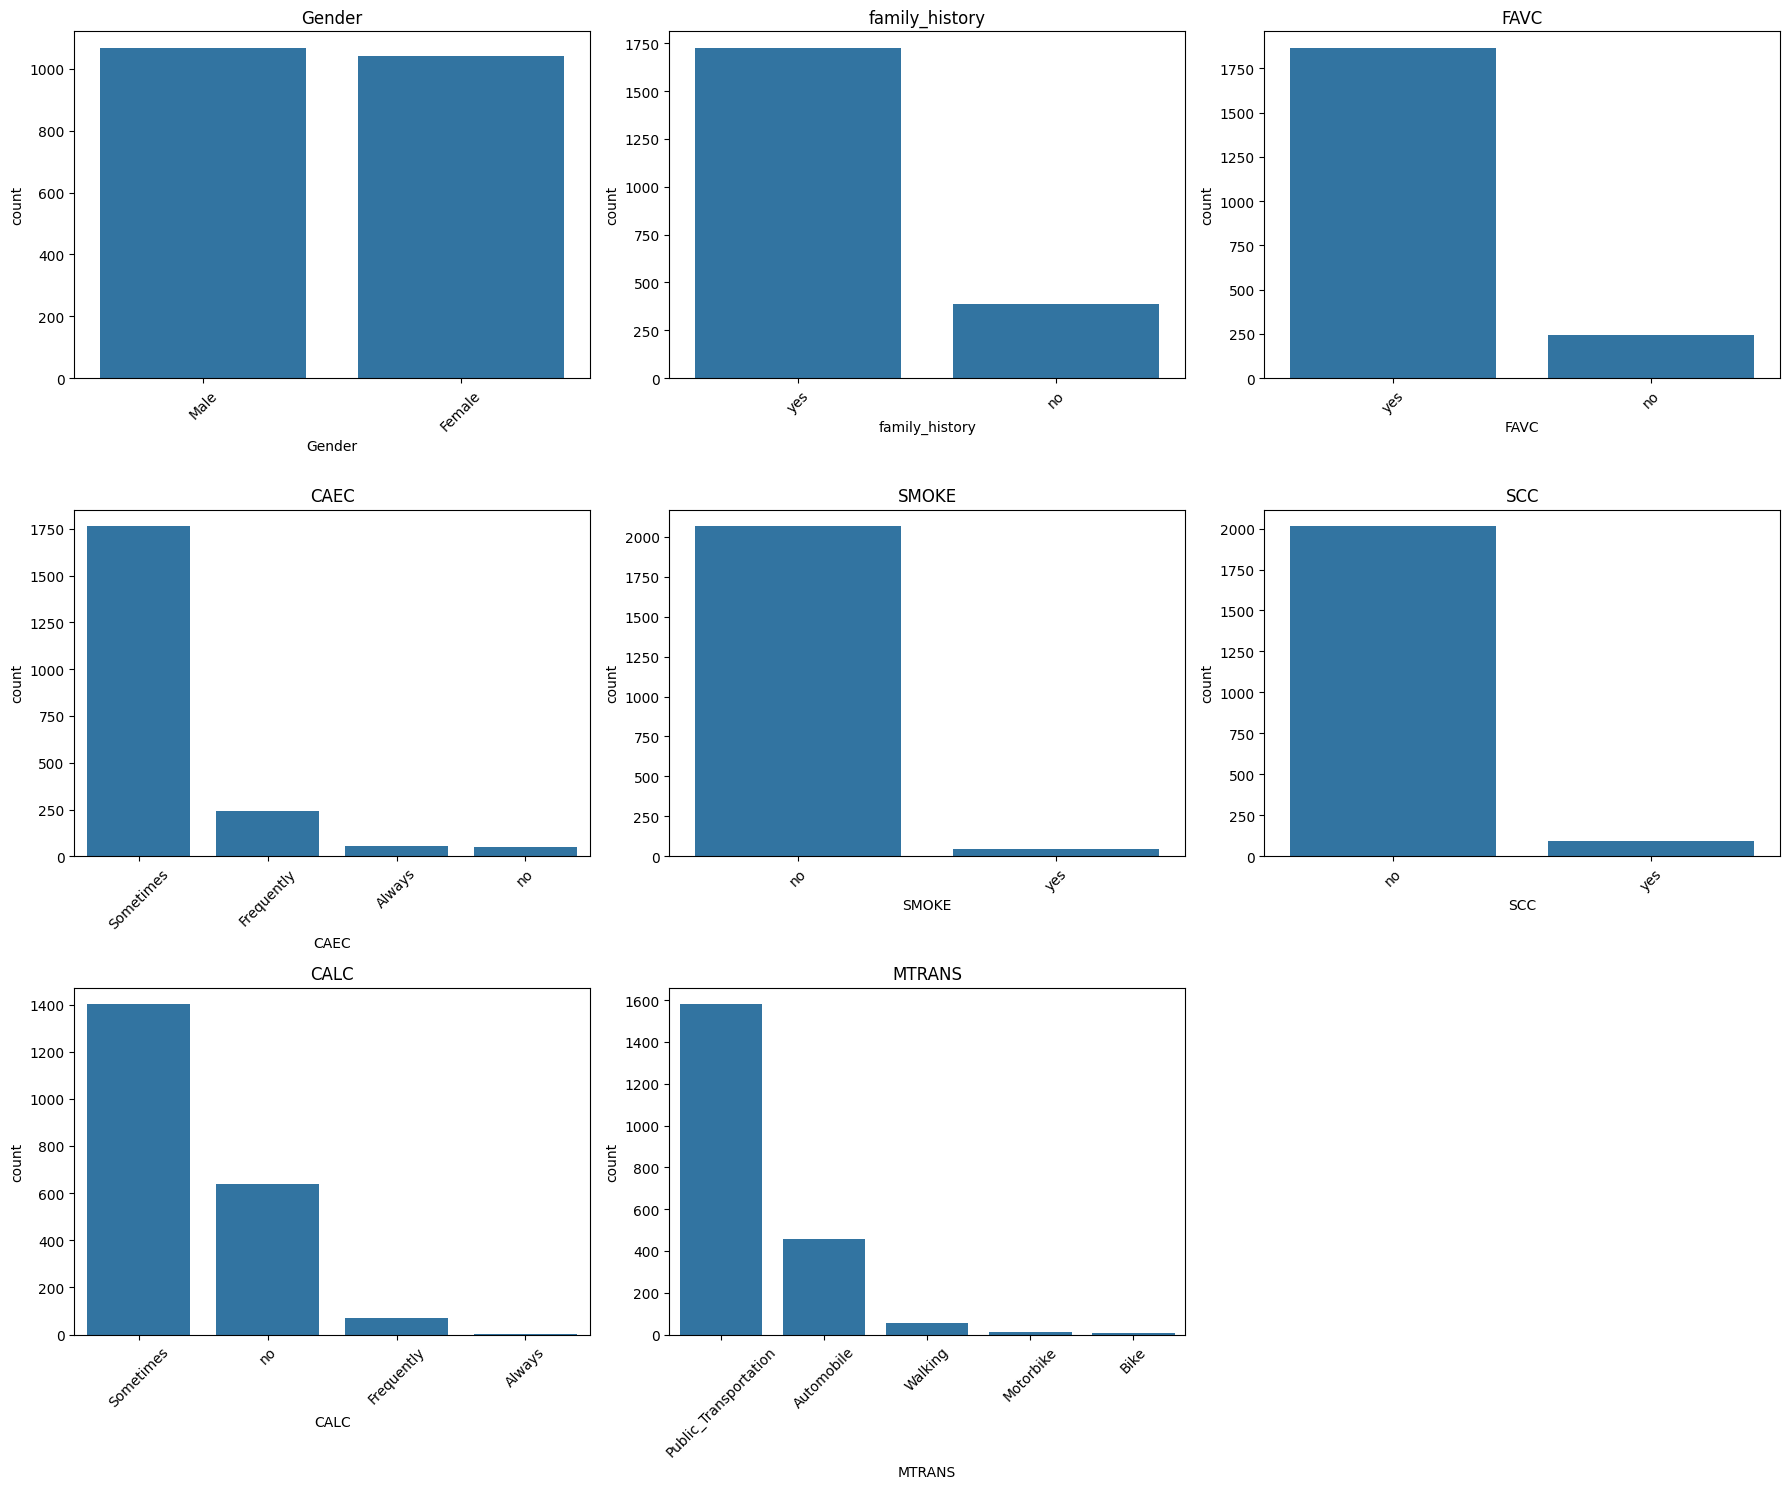

In [ ]:
# Univariate categorical analysis
def univariate_categorical_analysis(dataframe, columns):

    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5 * n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(columns):

        sns.countplot(
            data=dataframe,
            x=col,
            order=dataframe[col].value_counts().index,
            ax=axes[i]
        )

        axes[i].set_title(f"{col}")
        axes[i].tick_params(axis='x', rotation=45)

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


univariate_categorical_analysis(df, categorical_features)

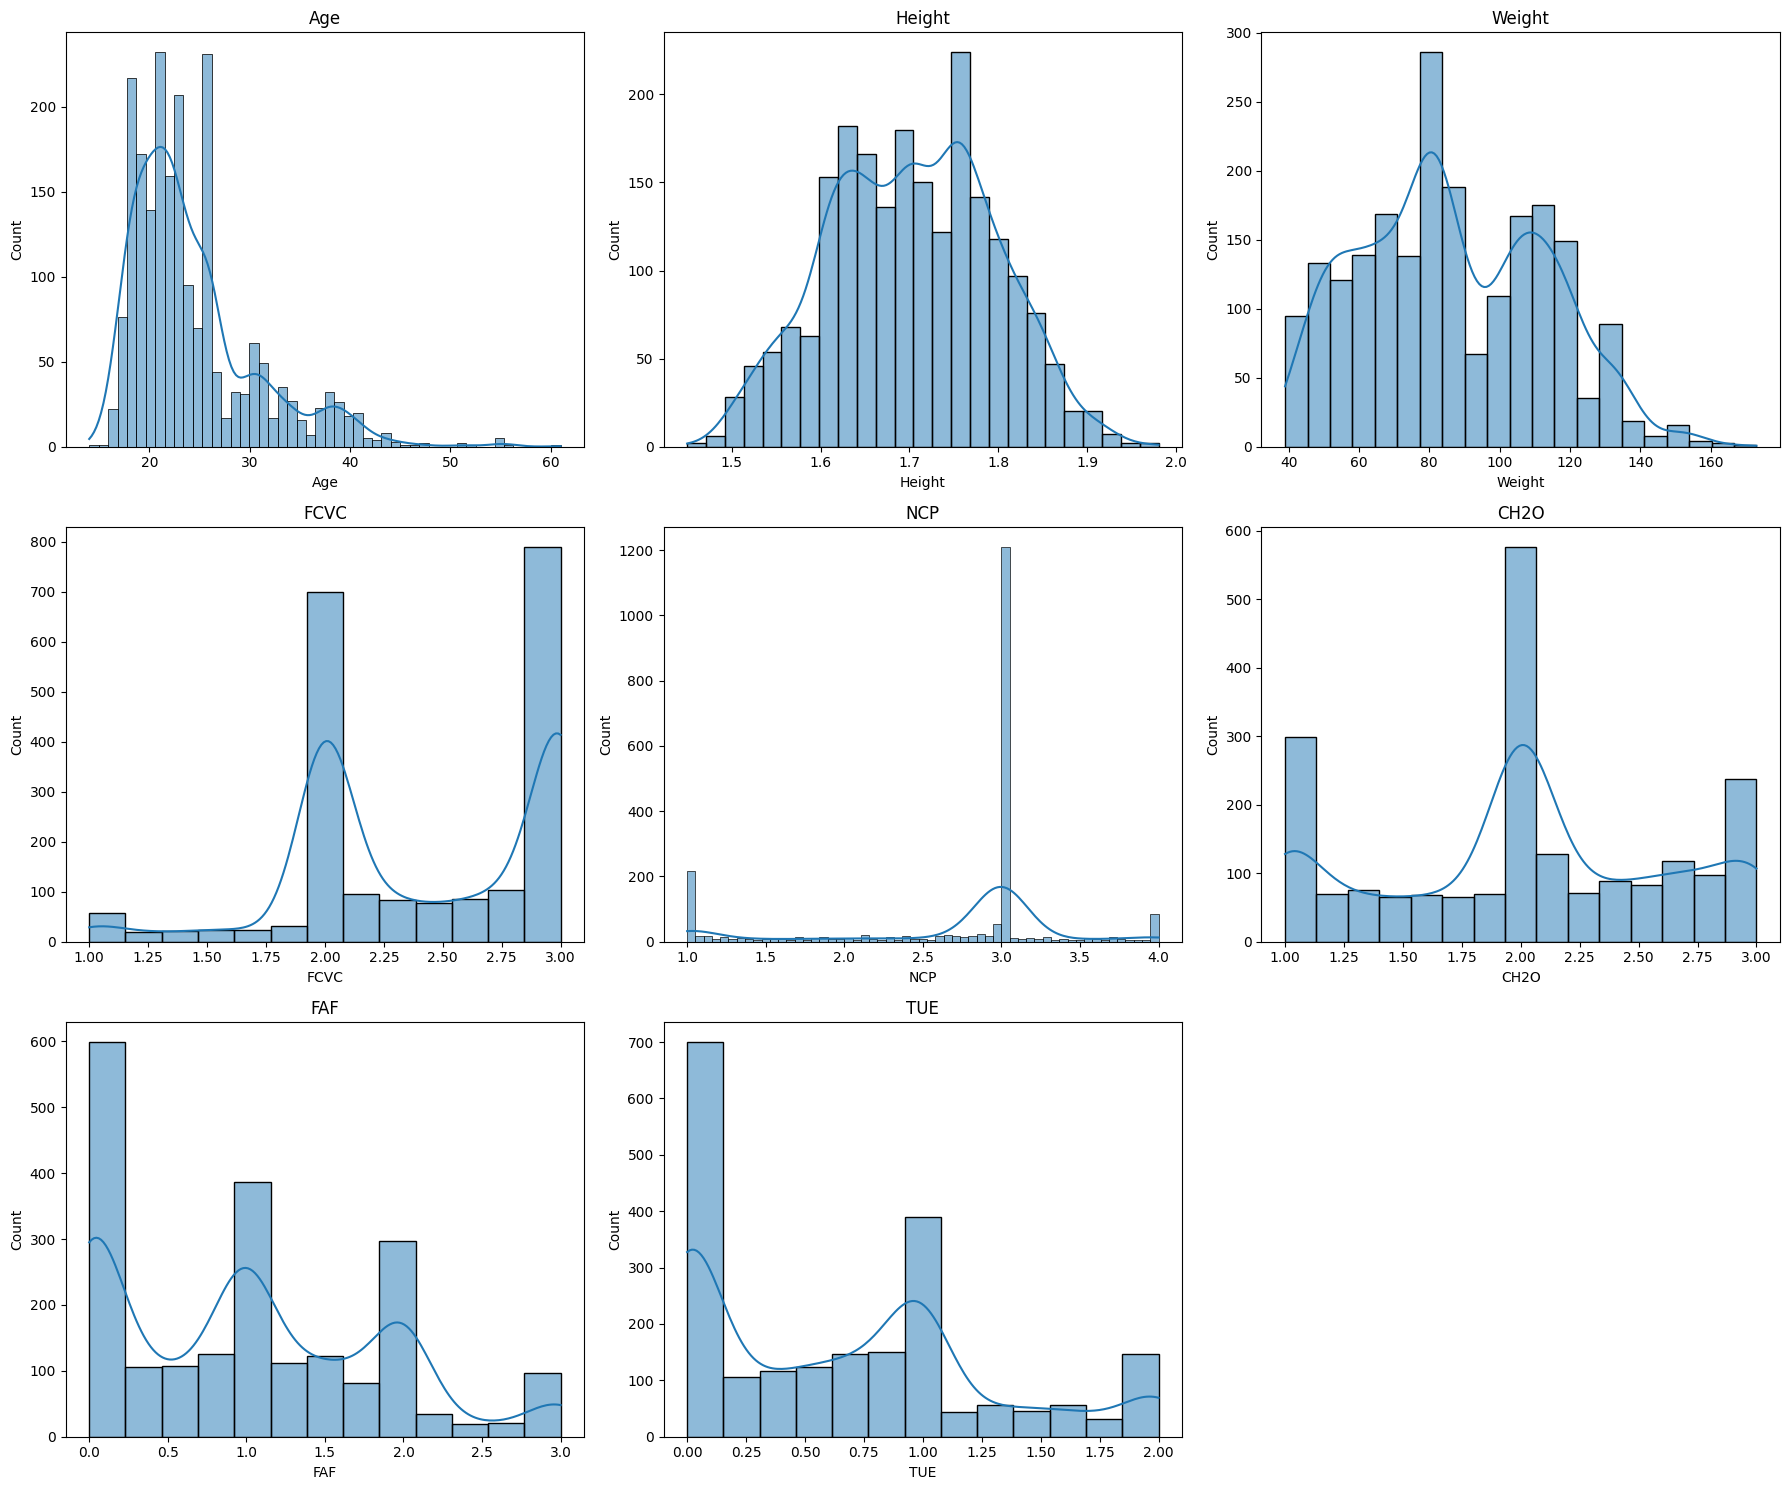

In [ ]:
# Univariate numerical analysis
def univariate_numerical_analysis(dataframe, columns):

    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5 * n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(columns):

        sns.histplot(
            data=dataframe,
            x=col,
            kde=True,
            ax=axes[i]
        )

        axes[i].set_title(f"{col}")

    # Remove empty subplot
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


univariate_numerical_analysis(df, numerical_features)

## 8 - Bivariate Features Analysis

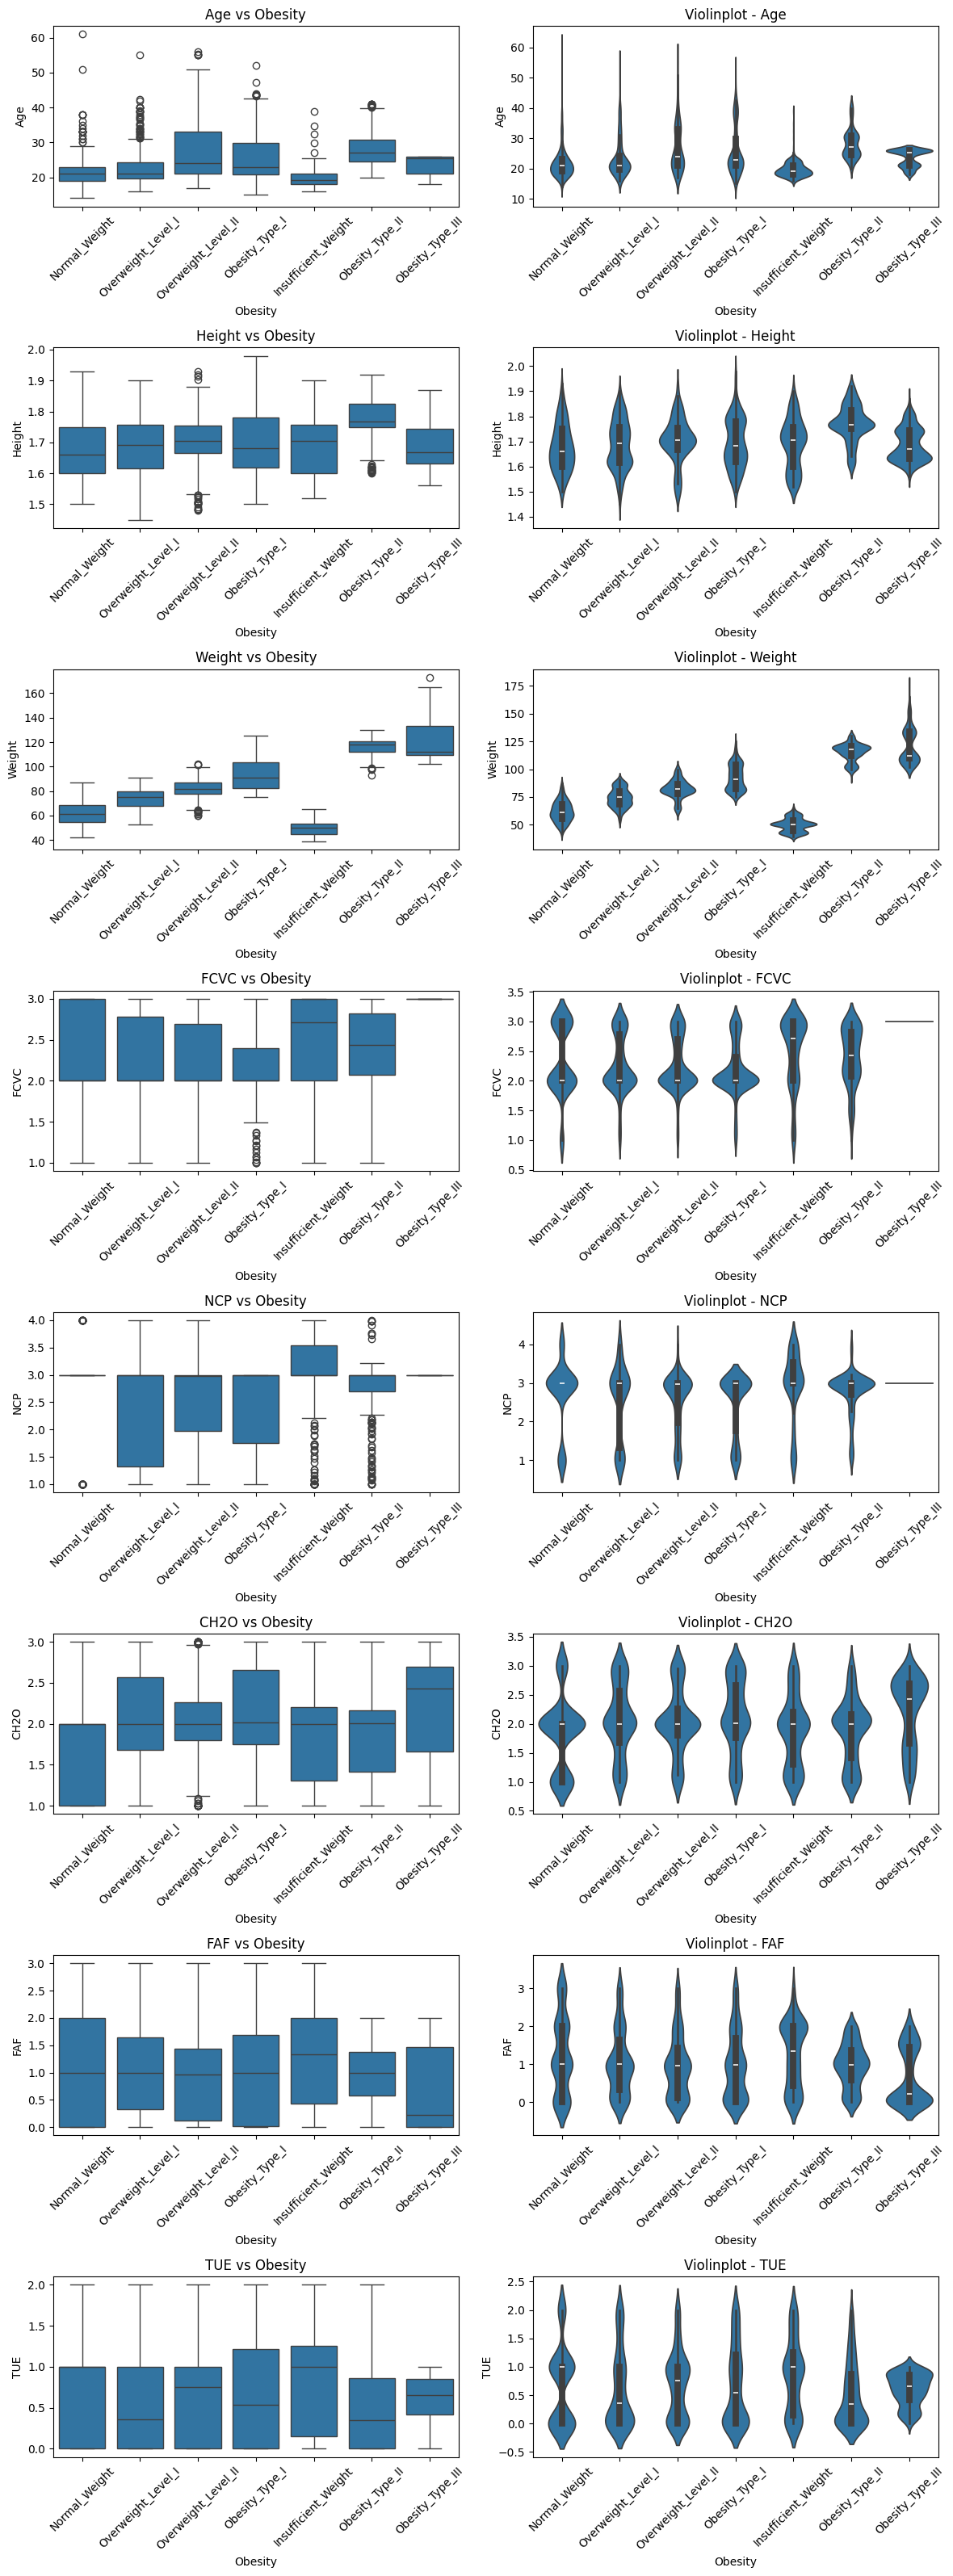

In [55]:
# Numerical Features vs Target
n_cols = 2
n_rows = len(numerical_features)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

for i, col in enumerate(numerical_features):

    # Boxplot
    sns.boxplot(
        data=df,
        x=target_column,
        y=col,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(f"{col} vs {target_column}")
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Violinplot
    sns.violinplot(
        data=df,
        x=target_column,
        y=col,
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(f"Violinplot - {col}")
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

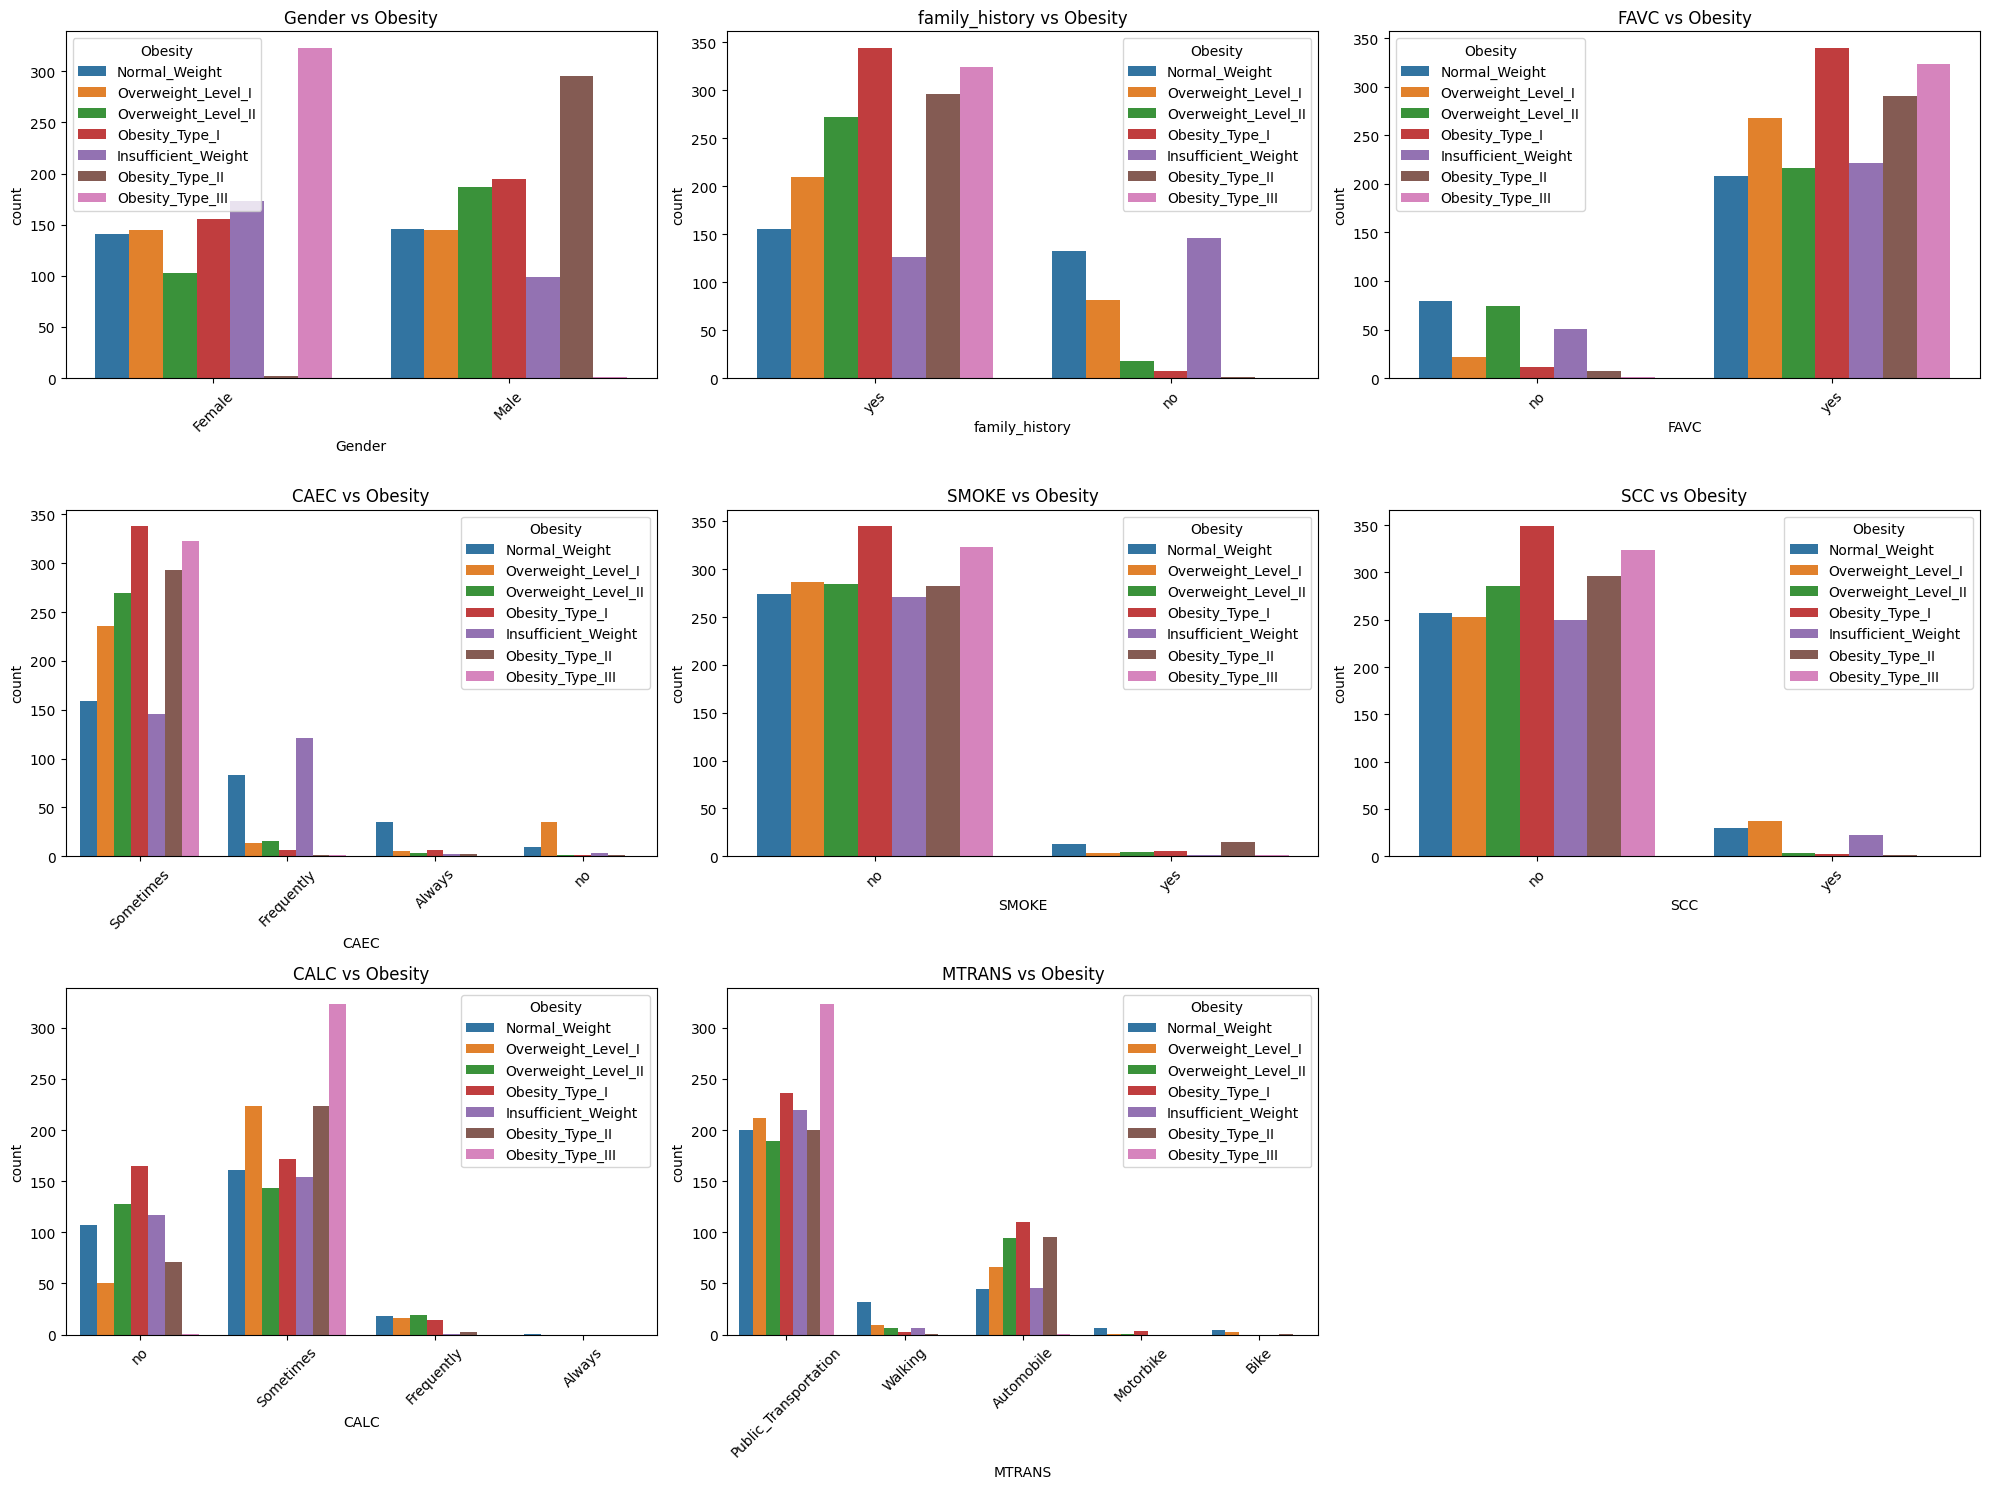

In [ ]:
# Categorical Features vs Target
n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_features):

    sns.countplot(
        data=df,
        x=col,
        hue=target_column,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs {target_column}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 9 - Correlation Heatmaps

In [27]:
df_encoded = df.copy()

le = LabelEncoder()

for col in categorical_features + [target_column]:
    df_encoded[col] = le.fit_transform(df_encoded[col])

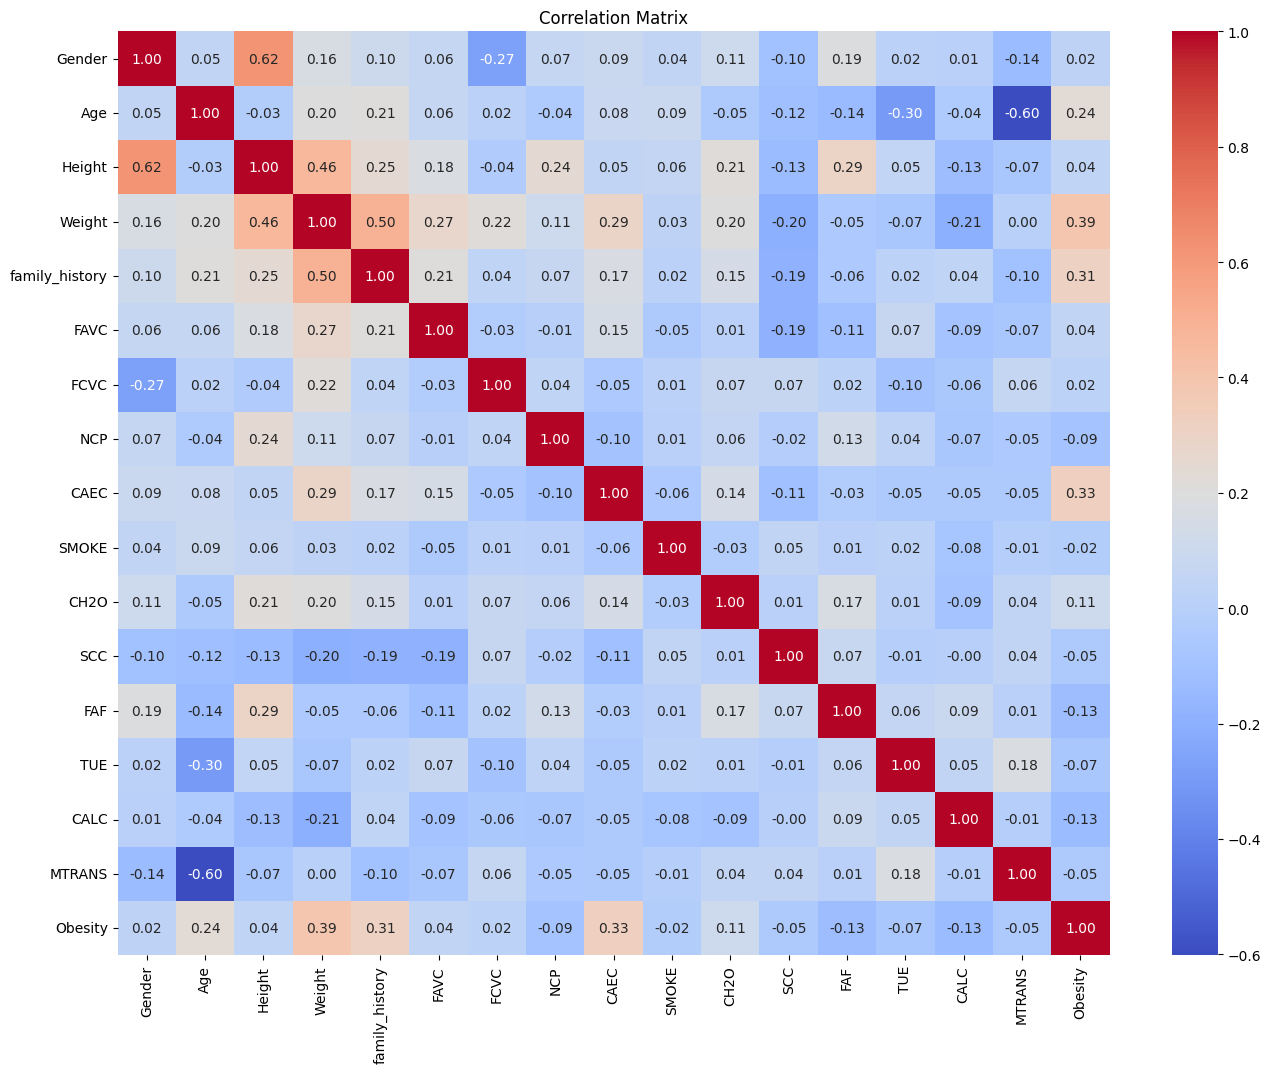

In [28]:
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [29]:
target_corr = correlation_matrix[target_column] \
    .sort_values(ascending=False)

print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH TARGET")
print("=" * 60)

print(target_corr)


FEATURE CORRELATION WITH TARGET
Obesity           1.000000
Weight            0.387643
CAEC              0.327295
family_history    0.313667
Age               0.236170
CH2O              0.108868
FAVC              0.044582
Height            0.038986
Gender            0.024908
FCVC              0.018522
SMOKE            -0.023256
MTRANS           -0.046202
SCC              -0.050679
TUE              -0.069448
NCP              -0.092616
FAF              -0.129564
CALC             -0.134632
Name: Obesity, dtype: float64


## 10 - Insight

# Result EDA - Obesity Dataset
---
## 1. Target Distribution Analysis

### Insight
- Distribusi target relatif seimbang antar kelas.
- Tidak terdapat class imbalance yang ekstrem.
- Dataset cocok untuk multiclass classification.

### Kesimpulan
- Oversampling kemungkinan tidak terlalu diperlukan.
- Tetap perlu evaluasi per-class menggunakan F1-score dan confusion matrix.

---

## 2. Univariate Analysis

### - Numerical Features

#### Age
- Distribusi cenderung right-skewed.
- Mayoritas usia berada pada rentang 18–30 tahun.
- Terdapat beberapa outlier usia tinggi.

#### Height
- Distribusi mendekati normal.
- Tidak banyak outlier ekstrem.

#### Weight
- Distribusi cukup lebar.
- Terdapat outlier pada berat badan tinggi.
- Memiliki indikasi hubungan kuat dengan obesity.

#### FCVC, CH2O, FAF, TUE
- Feature berbentuk behavioral scale.
- Distribusi tidak sepenuhnya continuous.

#### NCP
- Mayoritas data berada di nilai 3.
- Variasi feature relatif rendah.

---

### - Categorical Features

#### Gender
- Distribusi male dan female relatif seimbang.

#### family_history
- Mayoritas individu memiliki riwayat keluarga obesitas.

#### FAVC
- Mayoritas responden mengonsumsi makanan tinggi kalori.

#### SMOKE
- Sangat imbalance.
- Mayoritas bernilai "no".

#### SCC
- Distribusi tidak seimbang.

#### MTRANS
- Public transportation mendominasi.

---

## 3. Bivariate Analysis

### Weight vs Obesity
- Semakin tinggi obesity class, semakin tinggi weight.
- Weight menjadi feature paling kuat terhadap obesity.

### family_history vs Obesity
- Individu dengan family history = yes lebih dominan pada obesity tinggi.

### CAEC vs Obesity
- Kebiasaan ngemil memiliki hubungan terhadap tingkat obesitas.

### FAF vs Obesity
- Aktivitas fisik rendah lebih sering muncul pada obesity tinggi.

### Height vs Obesity
- Perbedaan antar class tidak terlalu signifikan.
- Height lebih potensial digunakan bersama Weight menjadi BMI.

---

## 4. Correlation Analysis

### Feature dengan Korelasi Tertinggi terhadap Obesity

| Feature | Correlation |
|---|---|
| Weight | 0.39 |
| CAEC | 0.33 |
| family_history | 0.31 |
| Age | 0.24 |

### Feature dengan Korelasi Negatif

| Feature | Correlation |
|---|---|
| FAF | -0.13 |
| CALC | -0.13 |

---

## 5. Multicollinearity Analysis

### Insight
- Tidak ditemukan multicollinearity berat.
- Tidak ada korelasi feature yang sangat tinggi (> 0.8).

### Kesimpulan
- Sebagian besar feature masih aman digunakan bersama.

---

## 6. Kesimpulan EDA

### Faktor yang Paling Berpengaruh terhadap Obesity
1. Weight
2. CAEC
3. family_history
4. Age

### Faktor Protektif
1. FAF (Physical Activity)

### Karakteristik Dataset
- Dataset cukup clean walau ada sedikit duplikat.
- Distribusi target balance.
- Banyak hubungan feature bersifat non-linear.
- Cocok untuk machine learning tabular.

---

## 7. Rencana Preprocessing

### Step 1 — Remove Duplicate
```python
df.drop_duplicates(inplace=True)
```

### Step 2 — Feature Engineering
#### Membuat Feature BMI
Rumus BMI:
BMI = Weight / Height²
```bash
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
```
### Step 3 — Encoding
#### A. Label Encoding

Digunakan untuk feature binary:

- yes/no
- male/female

Contoh feature:
- Gender
- family_history
- FAVC
- SMOKE
- SCC

### B. One Hot Encoding
Digunakan untuk feature multicategory:

- CAEC
- CALC
- MTRANS

Tujuan:
- menghindari false ordinal relationship
- lebih aman untuk machine learning model

---

## Step 4 — Feature Scaling
### StandardScaler

Digunakan untuk numerical features:

- Age
- Height
- Weight
- BMI
- FCVC
- NCP
- CH2O
- FAF
- TUE

Tujuan:
- menstabilkan distribusi feature
- membantu optimasi model machine learning

---

## Step 5 — Train Test Split
```python
train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
```

---

## 8. Modeling 
- Baseline models comparation
- Best model -> Hyperparameter tuning

---

## 9. Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report
